In [30]:
import boto3
from botocore.exceptions import ClientError
import json

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

In [31]:
import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

In [39]:
pip install -U pip setuptools wheel

Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install --only-binary=:all: "tiktoken>=0.7.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install "jupyter-ai-magics[all]" -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
safety-schemas 0.0.14 requires pydantic<2.10.0,>=2.6.0, but you have pydantic 2.12.0 which is incompatible.
sparkmagic 0.21.0 requires pandas<2.0.0,>=0.17.1, but you have pandas 2.2.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


# Select Assigned State (Ohio)

In [42]:
sql = """
     select * from population
     where fips = '39'
     """

In [43]:
import pandas as pd

q1_df = pd.read_sql(sql, con=conn)
q1_df.head()

,fips,pop,year
0,39,11155606,2005
1,39,11478006,2006
2,39,11466917,2007
3,39,11485910,2008
4,39,11542645,2009


# Q1: Population Growth Rate

In [45]:
import warnings
warnings.simplefilter('ignore')

In [46]:
import os
os.environ["OPENAI_API_KEY"] = get_secret('openai')['api_key']

In [47]:
%load_ext jupyter_ai_magics

In [48]:
%%ai gpt4 -f code
use the code in {q1_df} to visualize the growth rate of population

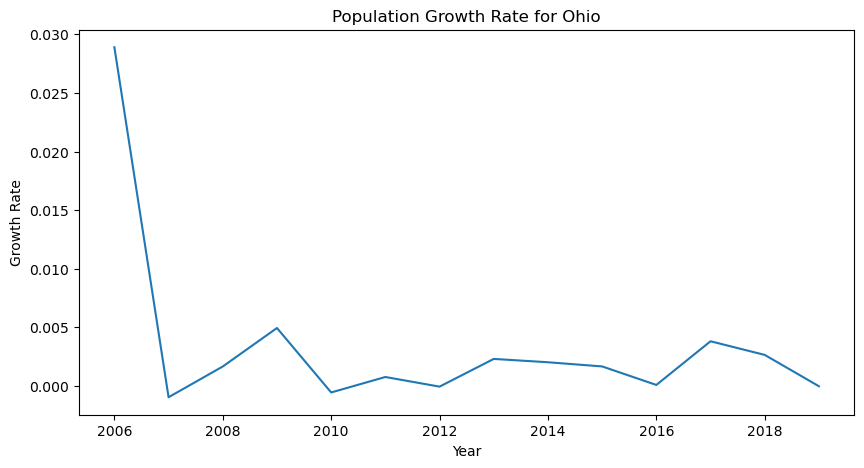

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame from the given data
data = {'fips': 39, 
        'pop': [11155606, 11478006, 11466917, 11485910, 11542645, 11536182, 11544951, 11544225, 
                11570808, 11594163, 11613423, 11614373, 11658609, 11689442, 11689100], 
        'year': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]}
df = pd.DataFrame(data)

# Calculate the growth rate
df['growth_rate'] = df['pop'].pct_change()

# Plot the growth rate
plt.figure(figsize=(10,5))
plt.plot(df['year'], df['growth_rate'])
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.title('Population Growth Rate for Ohio')
plt.show()

## Markdown for Q1

Ohio's population growth plumeted from 2006-2007. However, it seems to have stabilized from 2008-2018.

# Q2 Income and Population Relationship

In [50]:
sql = """
     select * from income
     where fips = '39'
     """

In [51]:
import pandas as pd

q2_df = pd.read_sql(sql, con=conn)
q2_df.head()

,fips,income,year
0,39,43493,2005
1,39,44532,2006
2,39,46597,2007
3,39,47988,2008
4,39,45395,2009


In [52]:
%%ai gpt4 -f code
use the data in {q1_df} and {q2_df} to join the income and population tables for your state, selecting values for all year.

In [53]:
# Create DataFrames from the given data
pop_data = {'fips': 39, 
            'pop': [11155606, 11478006, 11466917, 11485910, 11542645, 11536182, 11544951, 11544225, 
                    11570808, 11594163, 11613423, 11614373, 11658609, 11689442, 11689100], 
            'year': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]}
df_pop = pd.DataFrame(pop_data)

income_data = {'fips': 39, 
               'income': [43493, 44532, 46597, 47988, 45395, 45090, 45749, 46829, 48081, 49308, 
                          51075, 52334, 54021, 56111, 58642], 
               'year': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]}
df_income = pd.DataFrame(income_data)

# Join the two dataframes on the year column
df_combined = pd.merge(df_pop, df_income, on=['fips', 'year'])

df_combined

,fips,pop,year,income
0,39,11155606,2005,43493
1,39,11478006,2006,44532
2,39,11466917,2007,46597
3,39,11485910,2008,47988
4,39,11542645,2009,45395
5,39,11536182,2010,45090
6,39,11544951,2011,45749
7,39,11544225,2012,46829
8,39,11570808,2013,48081
9,39,11594163,2014,49308


In [54]:
%%ai gpt4 -f code
visualize the data in {merged_df}

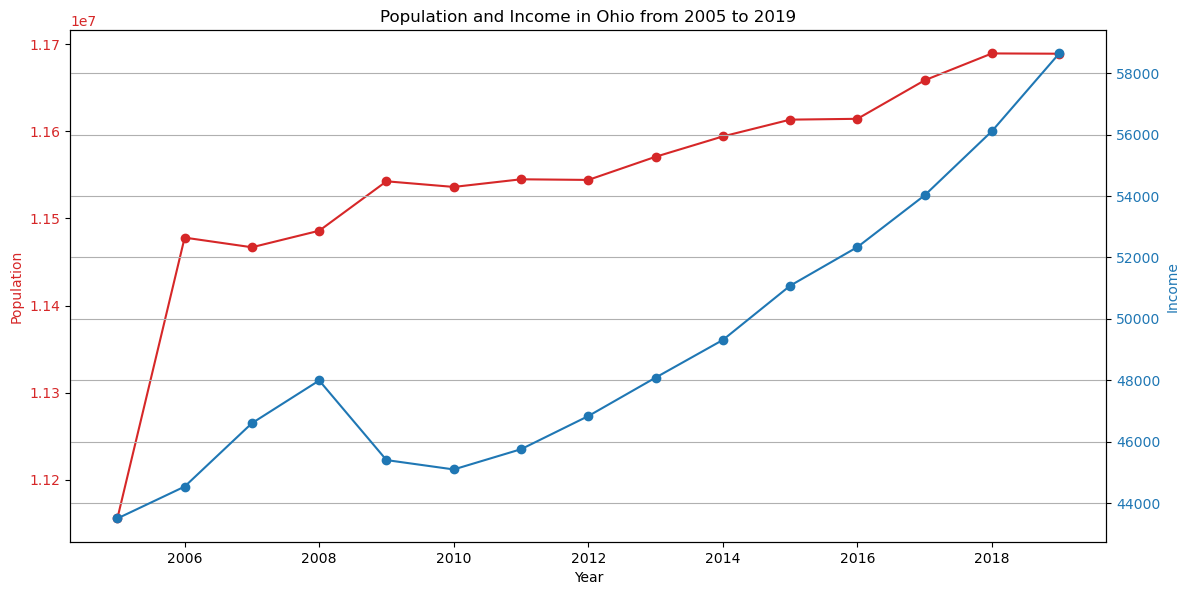

In [56]:
data = {
    'fips': [39]*15,
    'pop': [11155606, 11478006, 11466917, 11485910, 11542645, 11536182, 11544951, 11544225, 11570808, 11594163, 11613423, 11614373, 11658609, 11689442, 11689100],
    'year': list(range(2005, 2020)),
    'income': [43493, 44532, 46597, 47988, 45395, 45090, 45749, 46829, 48081, 49308, 51075, 52334, 54021, 56111, 58642]
}

df = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.subplots(figsize=(12,6))

color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Population', color=color)
ax1.plot(df['year'], df['pop'], color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Income', color=color)  
ax2.plot(df['year'], df['income'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout() 
plt.title('Population and Income in Ohio from 2005 to 2019')
plt.grid(True)
plt.show()

## Markdown for Q2

The graph maps the relationship between Ohio's population and the average income from 2005 to 2019. Based on the data we can see that the average income dropped in 2009, however it has been steadily rising since then. In contrast, the population of Ohio seems to be on a steady incline since 2006.

# Q3 Student-Defined Question

### Question - Which year had the smallest population growth rate?

In [57]:
%%ai gpt4 -f code
use the data in {q1_df} to create a visualization that shows which year had the smallest population growth rate

In [ ]:
df1['pop_growth_rate'] = df1['pop'].pct_change() 
min_growth_rate_year = df1[df1['pop_growth_rate'] == df1['pop_growth_rate'].min()]['year'].values[0]

plt.plot(df1['year'], df1['pop_growth_rate'], label='Population Growth Rate')
plt.axvline(x=min_growth_rate_year, color='r', linestyle='--', label=f'Smallest Growth Rate {min_growth_rate_year}')
plt.xlabel('Year')
plt.ylabel('Population Growth Rate')
plt.title('Yearly Population Growth Rate')
plt.legend()
plt.show()

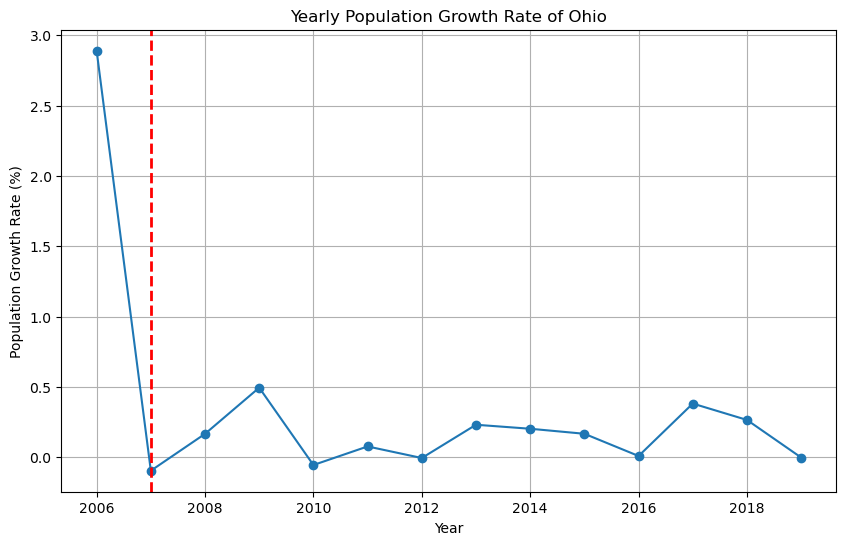

In [58]:
# Create DataFrame from the given data
pop_data = {'fips': 39, 
            'pop': [11155606, 11478006, 11466917, 11485910, 11542645, 11536182, 11544951, 11544225, 
                    11570808, 11594163, 11613423, 11614373, 11658609, 11689442, 11689100], 
            'year': [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]}
df_pop = pd.DataFrame(pop_data)

# Calculate the population growth rate
df_pop['pop_growth_rate'] = df_pop['pop'].pct_change()*100

# Plot the population growth rate
plt.figure(figsize=(10,6))
plt.plot(df_pop['year'], df_pop['pop_growth_rate'], marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Population Growth Rate (%)')
plt.title('Yearly Population Growth Rate of Ohio')
plt.grid(True)

# Highlight the year with the smallest growth rate
min_growth_year = df_pop['year'][df_pop['pop_growth_rate'].idxmin()]
plt.axvline(x=min_growth_year, color='r', linestyle='--', linewidth=2)

plt.show()

## Markdown for Q3

This graph is similar to the graph in Q1, it shows the population growth rate of Ohio from 2006-2018. The only difference is that it highlights the year with the lowest population growth rate, represented by the dotted red line. According to it, 2007 was the year with the lowest population growth rate.